# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_agmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈, 기존 이미지데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

In [5]:
image = load_img("./catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

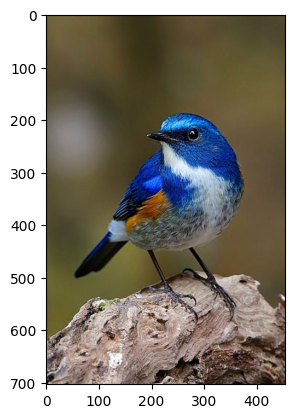

In [7]:
plt.imshow(image)
plt.show()

# Image Augmentation(이미지 증폭)

In [8]:
imggen = ImageDataGenerator(
            rescale= 1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'
            )

In [9]:
image_array.shape

(703, 454, 3)

차원 늘리기

In [11]:
image_array.reshape((1,) + image_array.shape).shape

(1, 703, 454, 3)

In [12]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

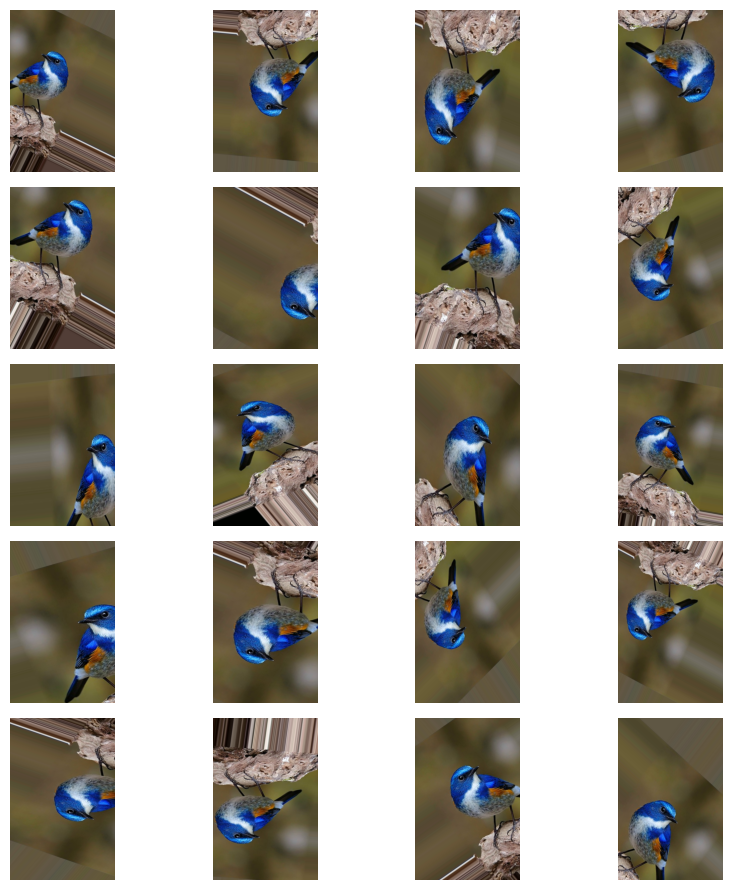

In [13]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augemtation을 이용한 개/고양이 분류모델 만들기

In [15]:
# 데이터 로드
train_dir = './catanddog/train/'
valid_dir = './catanddog/validation/'
batch_size = 16 # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16(큼) ~ 32(작음) 사이로 지정
image_size = (224, 224) # 모델의 입력 크기에 맞춤

In [16]:
# 이미지 증강
train_aug = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest')

valid_aug = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [17]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(224,224,3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(2, activation='softmax'))
cnn_model.summary()

I0000 00:00:1747708304.500818      44 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747708304.560276      44 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747708304.560372      44 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747708304.569116      44 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747708304.569193      44 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import tensorflow as tf

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000


I0000 00:00:1747709015.910809     189 service.cc:146] XLA service 0x7fa3dc001880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747709015.910985     189 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-05-20 02:43:35.966391: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-20 02:43:36.233697: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


  1/139 ━━━━━━━━━━━━━━━━━━━━ 14:02 6s/step - accuracy: 0.7500 - loss: 0.6577

I0000 00:00:1747709020.415435     189 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.4971 - loss: 0.7013
Epoch 1: val_loss improved from inf to 0.69742, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 61s 395ms/step - accuracy: 0.4971 - loss: 0.7013 - val_accuracy: 0.5000 - val_loss: 0.6974
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5019 - loss: 0.6945
Epoch 2: val_loss improved from 0.69742 to 0.68611, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.5019 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6861
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5332 - loss: 0.6921
Epoch 3: val_loss did not improve from 0.68611
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - accuracy: 0.5332 - loss: 0.6921 - val_accuracy: 0.5714 - val_loss: 0.6893
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5304 - loss: 0.6891
Epoch 4: val_loss improved from 0.68611 to 0.66300, saving mod

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6660 - loss: 0.6247
Epoch 24: val_loss did not improve from 0.54705
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.6662 - loss: 0.6245 - val_accuracy: 0.7143 - val_loss: 0.5584
Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6703 - loss: 0.6065
Epoch 25: val_loss improved from 0.54705 to 0.52697, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - accuracy: 0.6703 - loss: 0.6065 - val_accuracy: 0.7755 - val_loss: 0.5270
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6560 - loss: 0.6040
Epoch 26: val_loss did not improve from 0.52697
139/139 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.6561 - loss: 0.6041 - val_accuracy: 0.7245 - val_loss: 0.5276
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6793 - loss: 0.6013
Epoch 27: val_loss did not improve from 0.52697
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accur

139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.7262 - loss: 0.5299 - val_accuracy: 0.7755 - val_loss: 0.4726
Epoch 49/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7323 - loss: 0.5460
Epoch 49: val_loss did not improve from 0.47261
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.7322 - loss: 0.5460 - val_accuracy: 0.7551 - val_loss: 0.4884
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7351 - loss: 0.5265
Epoch 50: val_loss did not improve from 0.47261
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.7350 - loss: 0.5266 - val_accuracy: 0.6939 - val_loss: 0.5342
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7191 - loss: 0.5418
Epoch 51: val_loss did not improve from 0.47261
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.7191 - loss: 0.5417 - val_accuracy: 0.7347 - val_loss: 0.5082
Epoch 52/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7097 - loss: 0.5425
Epoch 52: va

139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - accuracy: 0.7596 - loss: 0.5000 - val_accuracy: 0.7653 - val_loss: 0.4585
Epoch 74/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7583 - loss: 0.5016
Epoch 74: val_loss did not improve from 0.45853
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.7583 - loss: 0.5016 - val_accuracy: 0.7449 - val_loss: 0.4750
Epoch 75/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7530 - loss: 0.5094
Epoch 75: val_loss improved from 0.45853 to 0.45045, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.7529 - loss: 0.5094 - val_accuracy: 0.8061 - val_loss: 0.4505
Epoch 76/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7691 - loss: 0.4796
Epoch 76: val_loss did not improve from 0.45045
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.7691 - loss: 0.4797 - val_accuracy: 0.7857 - val_loss: 0.4896
Epoch 77/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step

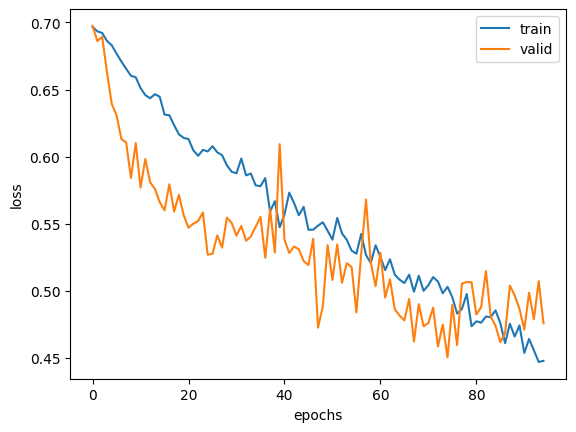

In [20]:
cnn_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/cnn_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
cnn_history = cnn_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [21]:
class_indices = valid_gen.class_indices
class_indices

{'Cat': 0, 'Dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


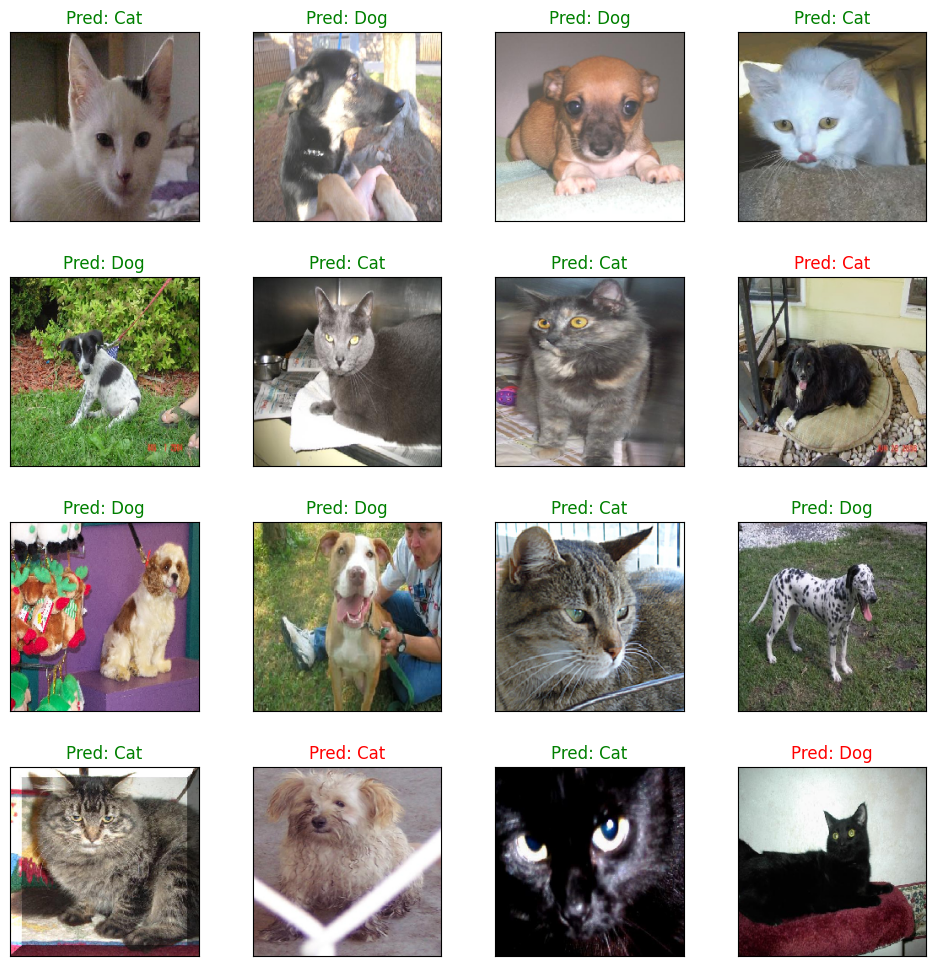


cnn_best_model평가 결과: Loss: 0.4063, Accuracy: 0.8125


In [24]:
# best 모델 로드
cnn_best_model = load_model("./model/cnn_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음

# ResNet50

In [25]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2

In [30]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

In [31]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [32]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [33]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])


Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5309 - loss: 0.7312

2025-05-20 05:38:57.797509: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1722', 16 bytes spill stores, 16 bytes spill loads




Epoch 1: val_loss improved from inf to 0.69365, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 263ms/step - accuracy: 0.5309 - loss: 0.7310 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5198 - loss: 0.6937
Epoch 2: val_loss improved from 0.69365 to 0.68920, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.5197 - loss: 0.6937 - val_accuracy: 0.5816 - val_loss: 0.6892
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5251 - loss: 0.6943
Epoch 3: val_loss did not improve from 0.68920
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 171ms/step - accuracy: 0.5250 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5130 - loss: 0.6927
Epoch 4: val_loss did not improve from 0.68920
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 182ms/step - accuracy: 0.5130 - loss: 0.6927 - val_acc

Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5115 - loss: 0.6943
Epoch 25: val_loss improved from 0.67787 to 0.67707, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.5117 - loss: 0.6943 - val_accuracy: 0.5918 - val_loss: 0.6771
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5190 - loss: 0.6898
Epoch 26: val_loss improved from 0.67707 to 0.67671, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.5190 - loss: 0.6898 - val_accuracy: 0.6122 - val_loss: 0.6767
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5500 - loss: 0.6891
Epoch 27: val_loss did not improve from 0.67671
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 186ms/step - accuracy: 0.5500 - loss: 0.6891 - val_accuracy: 0.5612 - val_loss: 0.6776
Epoch 28/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5319 - loss: 0.6865
Epoch 28: val_loss did not improve

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.5366 - loss: 0.6864
Epoch 48: val_loss did not improve from 0.67076
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.5366 - loss: 0.6864 - val_accuracy: 0.5816 - val_loss: 0.6709
Epoch 49/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5447 - loss: 0.6899
Epoch 49: val_loss did not improve from 0.67076
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - accuracy: 0.5446 - loss: 0.6899 - val_accuracy: 0.5714 - val_loss: 0.6709
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5401 - loss: 0.6837
Epoch 50: val_loss improved from 0.67076 to 0.66993, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - accuracy: 0.5401 - loss: 0.6837 - val_accuracy: 0.6633 - val_loss: 0.6699
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5502 - loss: 0.6834
Epoch 51: val_loss did not improve from 0.66993
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - acc

...

Epoch 120/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5606 - loss: 0.6839
Epoch 120: val_loss did not improve from 0.66058
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step - accuracy: 0.5607 - loss: 0.6839 - val_accuracy: 0.5612 - val_loss: 0.6643
Epoch 121/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5487 - loss: 0.6842
Epoch 121: val_loss did not improve from 0.66058
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.5487 - loss: 0.6842 - val_accuracy: 0.6735 - val_loss: 0.6618
Epoch 122/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.5711 - loss: 0.6817
Epoch 122: val_loss did not improve from 0.66058
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.5710 - loss: 0.6817 - val_accuracy: 0.5612 - val_loss: 0.6638
Epoch 123/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5772 - loss: 0.6797
Epoch 123: val_loss did not improve from 0.66058
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.5771 - loss: 0.679

Epoch 144/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5510 - loss: 0.6842
Epoch 144: val_loss did not improve from 0.65796
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 174ms/step - accuracy: 0.5511 - loss: 0.6842 - val_accuracy: 0.6224 - val_loss: 0.6590
Epoch 145/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5665 - loss: 0.6800
Epoch 145: val_loss did not improve from 0.65796
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.5664 - loss: 0.6800 - val_accuracy: 0.5714 - val_loss: 0.6616
Epoch 146/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5640 - loss: 0.6840
Epoch 146: val_loss did not improve from 0.65796
139/139 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.5640 - loss: 0.6840 - val_accuracy: 0.6327 - val_loss: 0.6588
Epoch 147/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5608 - loss: 0.6796
Epoch 147: val_loss did not improve from 0.65796
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.5609 - loss: 0.679

139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.5557 - loss: 0.6813 - val_accuracy: 0.6837 - val_loss: 0.6567
Epoch 169/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5262 - loss: 0.6854
Epoch 169: val_loss did not improve from 0.65652
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.5263 - loss: 0.6854 - val_accuracy: 0.6735 - val_loss: 0.6567
Epoch 170/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5663 - loss: 0.6810
Epoch 170: val_loss did not improve from 0.65652
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.5663 - loss: 0.6810 - val_accuracy: 0.6735 - val_loss: 0.6566
Epoch 171/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5872 - loss: 0.6777
Epoch 171: val_loss improved from 0.65652 to 0.65615, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - accuracy: 0.5872 - loss: 0.6777 - val_accuracy: 0.6939 - val_loss: 0.6561
Epoch 172/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1

Epoch 193/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5632 - loss: 0.6795
Epoch 193: val_loss did not improve from 0.65413
139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - accuracy: 0.5632 - loss: 0.6795 - val_accuracy: 0.5204 - val_loss: 0.6663
Epoch 194/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5806 - loss: 0.6745
Epoch 194: val_loss did not improve from 0.65413
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.5805 - loss: 0.6745 - val_accuracy: 0.6429 - val_loss: 0.6543
Epoch 195/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6020 - loss: 0.6751
Epoch 195: val_loss did not improve from 0.65413
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 172ms/step - accuracy: 0.6019 - loss: 0.6751 - val_accuracy: 0.6531 - val_loss: 0.6544
Epoch 196/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5522 - loss: 0.6836
Epoch 196: val_loss did not improve from 0.65413
139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.5522 - loss: 0.683

KeyboardInterrupt: 

In [34]:
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

NameError: name 'res50_history' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


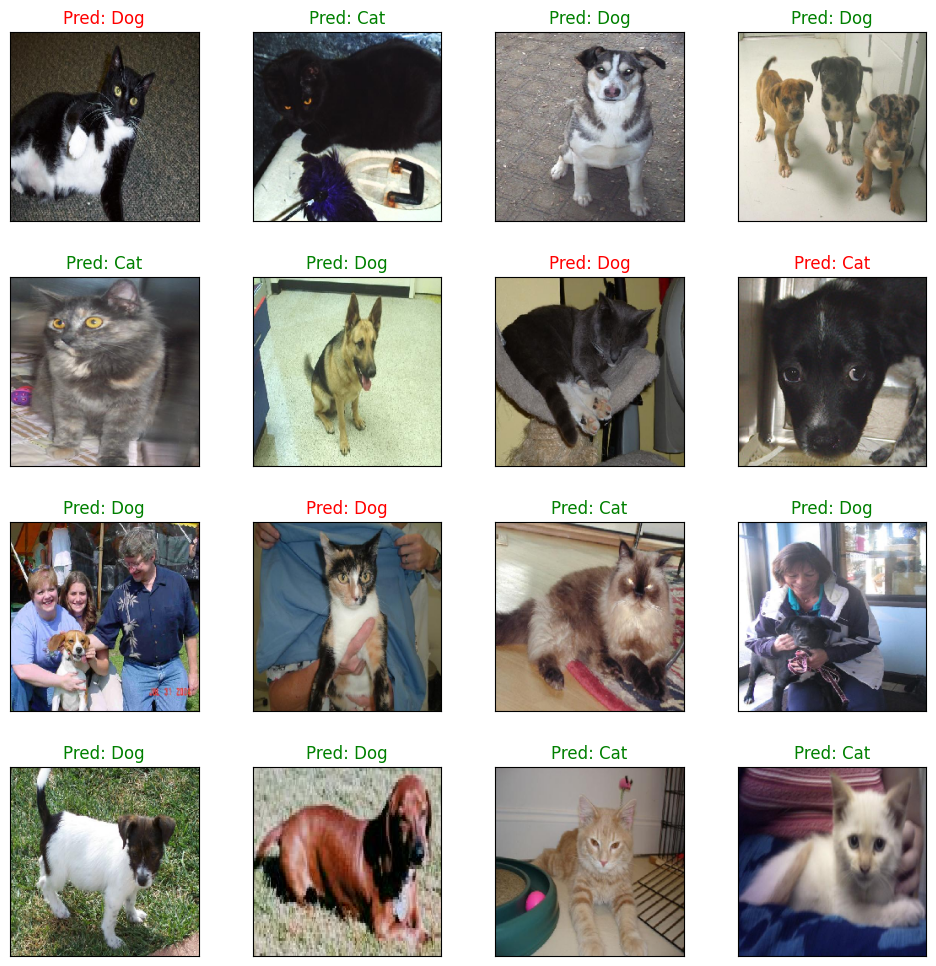


res50_best_model 평가 결과: Loss: 0.6289, Accuracy: 0.7500


In [38]:
# best 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = res50_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res50_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres50_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    

# ResNet152V2

In [39]:
base_model2 = ResNet152V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg'
)

In [40]:
base_model2.summary()

Model: "resnet152v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 58,331,648 (222.52 MB)

 Trainable params: 58,187,904 (221.97 MB)

 Non-trainable params: 143,744 (561.50 KB)

In [41]:
base_model2.trainable = False
res152v2_model = Sequential()
res152v2_model.add(base_model2)
res152v2_model.add(Dense(2, activation="softmax"))

Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5532 - loss: 0.9395
Epoch 1: val_loss improved from inf to 0.22436, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 68s 341ms/step - accuracy: 0.5540 - loss: 0.9378 - val_accuracy: 0.9184 - val_loss: 0.2244
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8548 - loss: 0.3089
Epoch 2: val_loss improved from 0.22436 to 0.12225, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 204ms/step - accuracy: 0.8550 - loss: 0.3087 - val_accuracy: 0.9694 - val_loss: 0.1222
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8997 - loss: 0.2433
Epoch 3: val_loss improved from 0.12225 to 0.09697, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.8998 - loss: 0.2431 - val_accuracy: 0.9694 - val_loss: 0.0970
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9188 - 

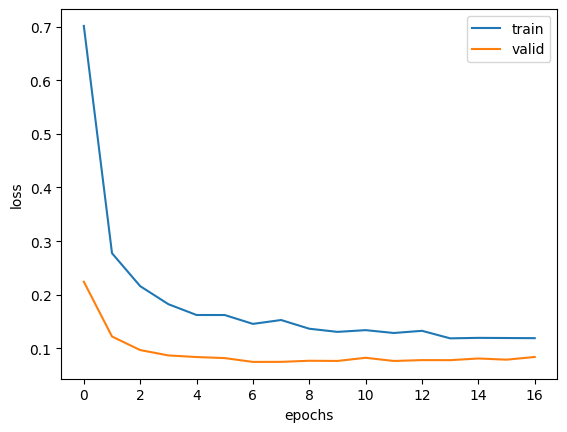

In [42]:
res152v2_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res152v2_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
res152v2_history = res152v2_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res152v2_history.history['loss'])
plt.plot(res152v2_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


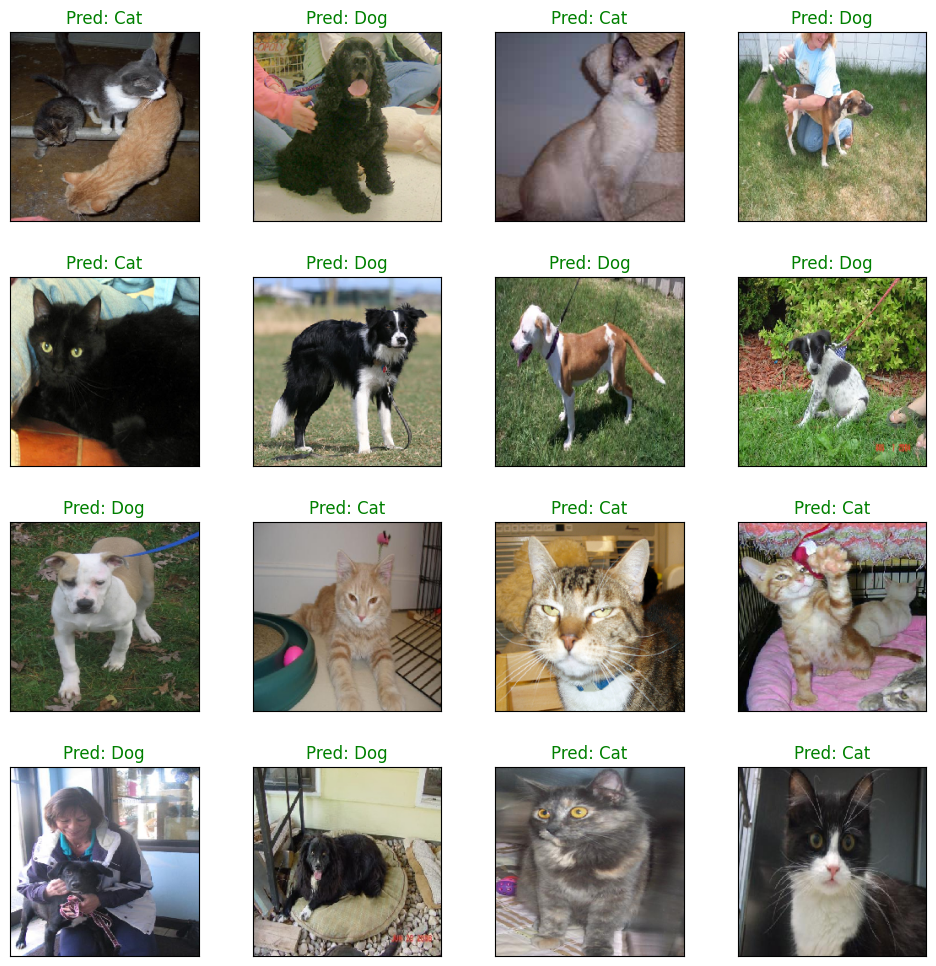


res152v2_best_model평가 결과: Loss: 0.0098, Accuracy: 1.0000


In [44]:
# best 모델 로드
res152v2_best_model = load_model("./model/res152v2_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = res152v2_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res152v2_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres152v2_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    

# convnextbase로 분석하기

In [50]:
from tensorflow.keras.applications import ConvNeXtBase

In [51]:
# 이미지 증강
train_aug2 = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest')

valid_aug2 = ImageDataGenerator()

# 이미지 제너레이터
train_gen2 = train_aug2.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen2 = valid_aug2.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch2, y_batch2 = next(train_gen2)
print(X_batch2.shape)
print(y_batch2.shape)
print(train_gen2.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [52]:
base_model3 = ConvNeXtBase(
    include_top=True,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation="softmax",
    name="convnext_base",
)

In [53]:
base_model3.trainable = False
ConvNeXtBase_model = Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation="softmax"))

In [ ]:
ConvNeXtBase_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/ConvNeXtBase_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
ConvNeXtBase_history = ConvNeXtBase_model.fit(train_gen2, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.2982 - loss: 0.7001
Epoch 1: val_loss improved from inf to 0.69298, saving model to ./model/ConvNeXtBase_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 54s 282ms/step - accuracy: 0.2985 - loss: 0.7001 - val_accuracy: 0.5102 - val_loss: 0.6930
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5047 - loss: 0.6932
Epoch 2: val_loss improved from 0.69298 to 0.69277, saving model to ./model/ConvNeXtBase_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 207ms/step - accuracy: 0.5050 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6917 - loss: 0.6866
Epoch 3: val_loss improved from 0.69277 to 0.69256, saving model to ./model/ConvNeXtBase_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 204ms/step - accuracy: 0.6920 - loss: 0.6866 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accurac

In [ ]:
# best 모델 로드
ConvNeXtBase_best_model = load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen2.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen2))

cnn_pred = ConvNeXtBase_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = ConvNeXtBase_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nConvNeXtBase_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    